In [1]:
!pip install qiskit qiskit-machine-learning qiskit-aer --quiet
!git clone https://github.com/irembuseozkose/QCNN-For-Skin-Cancer.git
%cd QCNN-For-Skin-Cancer
!ls

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 79.2 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 98.1 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.8 MB/s eta 0:00:00
Cloning into 'QCNN-For-Skin-Cancer'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 15 (delta 0), reused 15 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 11.78 KiB | 5.89 MiB/s, done.
/content/QCNN-For-Skin-Cancer
notebooks  requirements.txt  src


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [4]:
!mkdir -p /content/data/processed
!unzip -q /content/drive/MyDrive/QCNN/features_q.zip -d /content/data/processed
!ls /content/data/processed/features_q

pca_components.npy  X_test.npy	       X_val_small.npy	  y_val.npy
pca_mean.npy	    X_train.npy        y_test.npy	  y_val_small.npy
scaler_mean.npy     X_train_small.npy  y_train.npy
scaler_scale.npy    X_val.npy	       y_train_small.npy


In [5]:
from pathlib import Path
from src.qcnn.train import TrainConfig, fit

cfg = TrainConfig(
    data_dir=Path("/content/data/processed/features_q"),
    n_qubits=8,
    n_blocks=1,
    measured_qubits=[0,1,2,3],
    n_classes=9,
    batch_size=8,
    epochs=15,
    lr=1e-3,
    eps=1e-10,
    seed=42,
)

model, history = fit(cfg)

Epoch 001 | train loss 19.2844 acc 0.0820 | val loss 17.5894 acc 0.1310
Epoch 002 | train loss 14.7221 acc 0.1298 | val loss 11.7098 acc 0.1548
Epoch 003 | train loss 10.7913 acc 0.1530 | val loss 9.1360 acc 0.1518
Epoch 004 | train loss 7.6052 acc 0.1529 | val loss 6.3766 acc 0.1458
Epoch 005 | train loss 4.9878 acc 0.1544 | val loss 4.3446 acc 0.1458
Epoch 006 | train loss 3.9903 acc 0.1592 | val loss 3.8482 acc 0.1429
Epoch 007 | train loss 3.6071 acc 0.1550 | val loss 3.4861 acc 0.1429
Epoch 008 | train loss 3.3631 acc 0.1513 | val loss 3.3140 acc 0.1250
Epoch 009 | train loss 3.2054 acc 0.1565 | val loss 3.2727 acc 0.1369
Epoch 010 | train loss 3.1044 acc 0.1530 | val loss 3.1268 acc 0.1250
Epoch 011 | train loss 3.0365 acc 0.1492 | val loss 3.0692 acc 0.1250
Epoch 012 | train loss 2.9926 acc 0.1498 | val loss 3.0105 acc 0.1250
Epoch 013 | train loss 2.9231 acc 0.1504 | val loss 2.9706 acc 0.1280
Epoch 014 | train loss 2.9162 acc 0.1497 | val loss 2.9534 acc 0.1310
Epoch 015 | tra

In [6]:
best_epoch = max(range(len(history["val"])), key=lambda i: history["val"][i]["acc"]) + 1

print("Best epoch:", best_epoch)
print("Train:", history["train"][best_epoch-1])
print("Val  :", history["val"][best_epoch-1])

Best epoch: 2
Train: {'loss': 14.722134339709243, 'acc': 0.12980192079514014}
Val  : {'loss': 11.709750902085077, 'acc': 0.15476190476190477}


In [7]:
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix, classification_report

def qcnn_predict(model, X_np, batch_size=8):
    model.eval()
    dl = DataLoader(TensorDataset(torch.from_numpy(X_np.astype(np.float32))), batch_size=batch_size)
    probs_all = []
    with torch.no_grad():
        for (Xb,) in dl:
            probs16 = model(Xb)
            probs9 = probs16[:, :9]
            probs9 = torch.clamp(probs9, min=1e-10)
            probs9 = probs9 / probs9.sum(dim=1, keepdim=True)
            probs_all.append(probs9.cpu().numpy())
    probs_all = np.concatenate(probs_all, axis=0)
    y_pred = probs_all.argmax(axis=1)
    return y_pred, probs_all

DATA_DIR = Path("/content/data/processed/features_q")

X_test = np.load(DATA_DIR/"X_test.npy")
y_test = np.load(DATA_DIR/"y_test.npy")

y_pred, probs_test = qcnn_predict(model, X_test)

acc = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
weighted_f1 = f1_score(y_test, y_pred, average="weighted")
macro_prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
macro_rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)

print("TEST METRICS")
print("Accuracy     :", acc)
print("Macro F1     :", macro_f1)
print("Weighted F1  :", weighted_f1)
print("Macro Prec   :", macro_prec)
print("Macro Recall :", macro_rec)

print("\nClassification Report")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))

print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

TEST METRICS
Accuracy     : 0.1271186440677966
Macro F1     : 0.11692380607446329
Weighted F1  : 0.1151443057179891
Macro Prec   : 0.13689006466784245
Macro Recall : 0.13425925925925924

Classification Report
              precision    recall  f1-score   support

           0     0.2857    0.1250    0.1739        16
           1     0.0000    0.0000    0.0000        16
           2     0.2000    0.0625    0.0952        16
           3     0.1944    0.4375    0.2692        16
           4     0.1667    0.0625    0.0909        16
           5     0.1111    0.0625    0.0800        16
           6     0.0000    0.0000    0.0000         3
           7     0.0741    0.1250    0.0930        16
           8     0.2000    0.3333    0.2500         3

    accuracy                         0.1271       118
   macro avg     0.1369    0.1343    0.1169       118
weighted avg     0.1450    0.1271    0.1151       118

Confusion Matrix
[[2 4 0 2 0 3 2 3 0]
 [1 0 1 4 4 1 1 3 1]
 [0 3 1 5 1 1 0 5 0]
 [0 2 

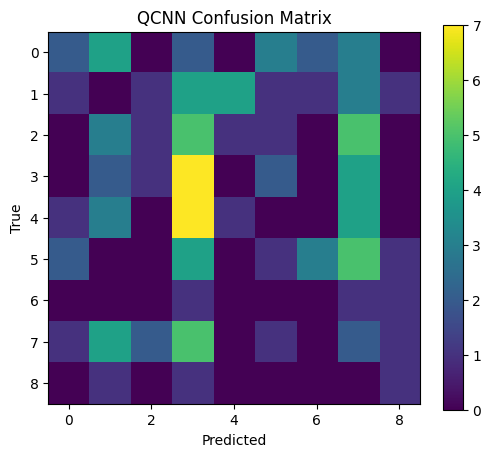

In [8]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("QCNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()